# **Sentiment Analysis**

**Import Libraries**

In [ ]:
!pip install tensorflow numpy pandas matplotlib seaborn scikit-learn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from sklearn.metrics import confusion_matrix, classification_report


**Load IMDB Dataset**

In [ ]:
vocab_size = 10000

(x_train,y_train),(x_test,y_test) = imdb.load_data(num_words=vocab_size)

print("Train Data:",len(x_train))
print("Test Data:",len(x_test))
print("Sample Label:",y_train[0], "-> 1=Positive, 0=Negative")
print("Sample Review Length:",len(x_train[0]))
print("sample Review(numbers):",x_train[0][:10])

Train Data: 25000
Test Data: 25000
Sample Label: 1 -> 1=Positive, 0=Negative
Sample Review Length: 218
sample Review(numbers): [1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65]


**Sequences Train&Test**

In [ ]:
max_length = 250
x_train_pad = pad_sequences(x_train,maxlen=max_length)
x_test_pad = pad_sequences(x_test,maxlen=max_length)

print("x_train shape:",x_train_pad.shape)
print("x_test shape:",x_test_pad.shape)

unique, counts = np.unique(y_train, return_counts=True)
print("\nClass Distribution:")
for u, c in zip(unique, counts):
    label="positive" if u==1 else "Negative"
    print(f"  {label}: {c}")

x_train shape: (25000, 250)
x_test shape: (25000, 250)

Class Distribution:
  Negative: 12500
  positive: 12500


**Build RNN Model**

In [ ]:
model=Sequential()

model.add(Embedding(vocab_size,128))

model.add(SimpleRNN(32, return_sequences=True))
model.add(Dropout(0.3))

model.add(SimpleRNN(64, return_sequences=False))
model.add(Dropout(0.3))

model.add(Dense(64,activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(1, activation="sigmoid"))

model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.build(input_shape=(None, max_length))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 250, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 250, 32)        │         5,152 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 250, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_1 (SimpleRNN)        │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,295,585 (4.94 MB)

 Trainable params: 1,295,585 (4.94 MB)

 Non-trainable params: 0 (0.00 B)

**Train RNN**

In [ ]:
history=model.fit(
    x_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(x_test_pad,y_test),
    verbose=1
)
print("Training Completed")

Epoch 1/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 96s 246ms/step - accuracy: 0.9653 - loss: 0.0901 - val_accuracy: 0.6957 - val_loss: 0.8557
Epoch 2/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 211ms/step - accuracy: 0.9725 - loss: 0.0780 - val_accuracy: 0.7914 - val_loss: 0.8659
Epoch 3/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 83s 211ms/step - accuracy: 0.9896 - loss: 0.0304 - val_accuracy: 0.7984 - val_loss: 1.1014
Epoch 4/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 88s 225ms/step - accuracy: 0.9968 - loss: 0.0110 - val_accuracy: 0.7978 - val_loss: 1.1573
Epoch 5/5
391/391 ━━━━━━━━━━━━━━━━━━━━ 82s 211ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.8060 - val_loss: 1.0705
Training Completed


Evaluate Model

In [ ]:
test_loss,test_accuracy=model.evaluate(x_test_pad,y_test)
print(f"Test Accuracy:{test_accuracy*100:.2f}%")
print(f"Test Loss:{test_loss:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step - accuracy: 0.8060 - loss: 1.0705
Test Accuracy:80.60%
Test Loss:1.0705


Accuracy&Loss Plot Visualization

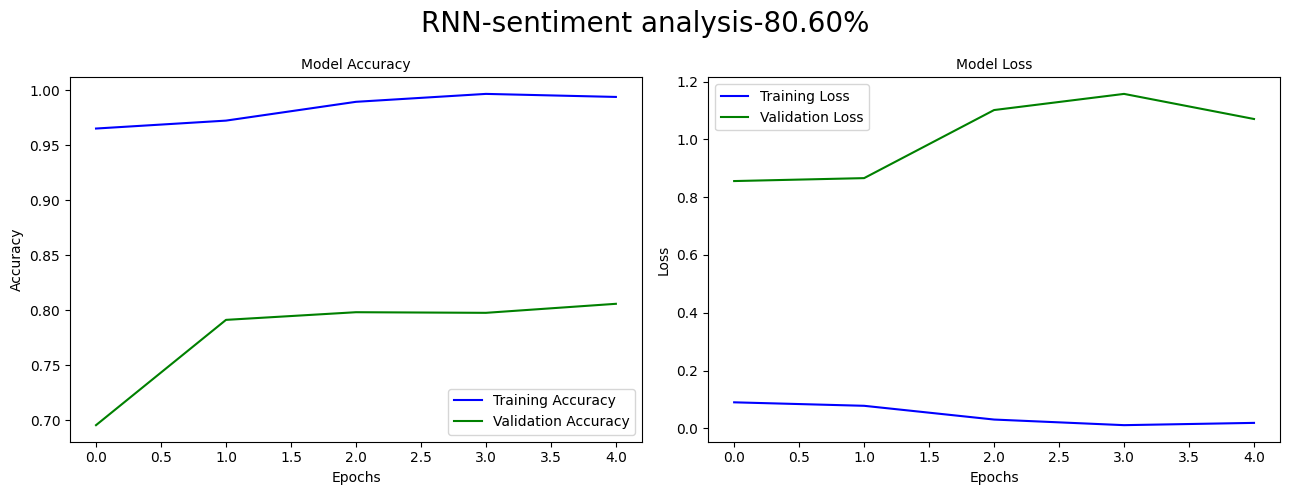

In [ ]:
fig,axes=plt.subplots(1,2,figsize=(13,5))

#accuracy plot

axes[0].plot(history.history["accuracy"],color="blue",label="Training Accuracy")
axes[0].plot(history.history["val_accuracy"],color="green",label="Validation Accuracy")
axes[0].set_title("Model Accuracy",fontsize=10)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

#loss plot

axes[1].plot(history.history["loss"],color="blue",label="Training Loss")
axes[1].plot(history.history["val_loss"],color="green",label="Validation Loss")
axes[1].set_title("Model Loss", fontsize=10)
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.suptitle("RNN-sentiment analysis-80.60%",fontsize=20)
plt.tight_layout()
plt.show()

**Confusion matrix visualization**

782/782 ━━━━━━━━━━━━━━━━━━━━ 26s 34ms/step


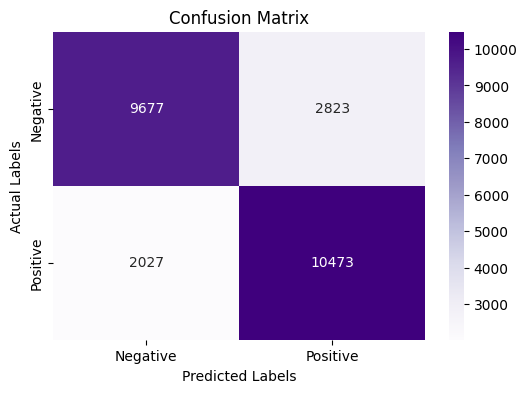

              precision    recall  f1-score   support

    Negative       0.83      0.77      0.80     12500
    Positive       0.79      0.84      0.81     12500

    accuracy                           0.81     25000
   macro avg       0.81      0.81      0.81     25000
weighted avg       0.81      0.81      0.81     25000

Accuracy: 0.806
Precision: 0.7876805054151624
Recall: 0.83784
F1 Score: 0.8119863544735618


In [ ]:
y_pred_prob=model.predict(x_test_pad)
y_pred=(y_pred_prob>0.5).astype(int)

CFM = confusion_matrix(y_test,y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(CFM,annot=True,fmt="d",xticklabels=["Negative","Positive"],yticklabels=["Negative","Positive"],cmap="Purples")
plt.xlabel("Predicted Labels")
plt.ylabel("Actual Labels")
plt.title("Confusion Matrix")
plt.show()
print(classification_report(y_test,y_pred,target_names=['Negative','Positive']))

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Four Type Visualization

782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 31ms/step


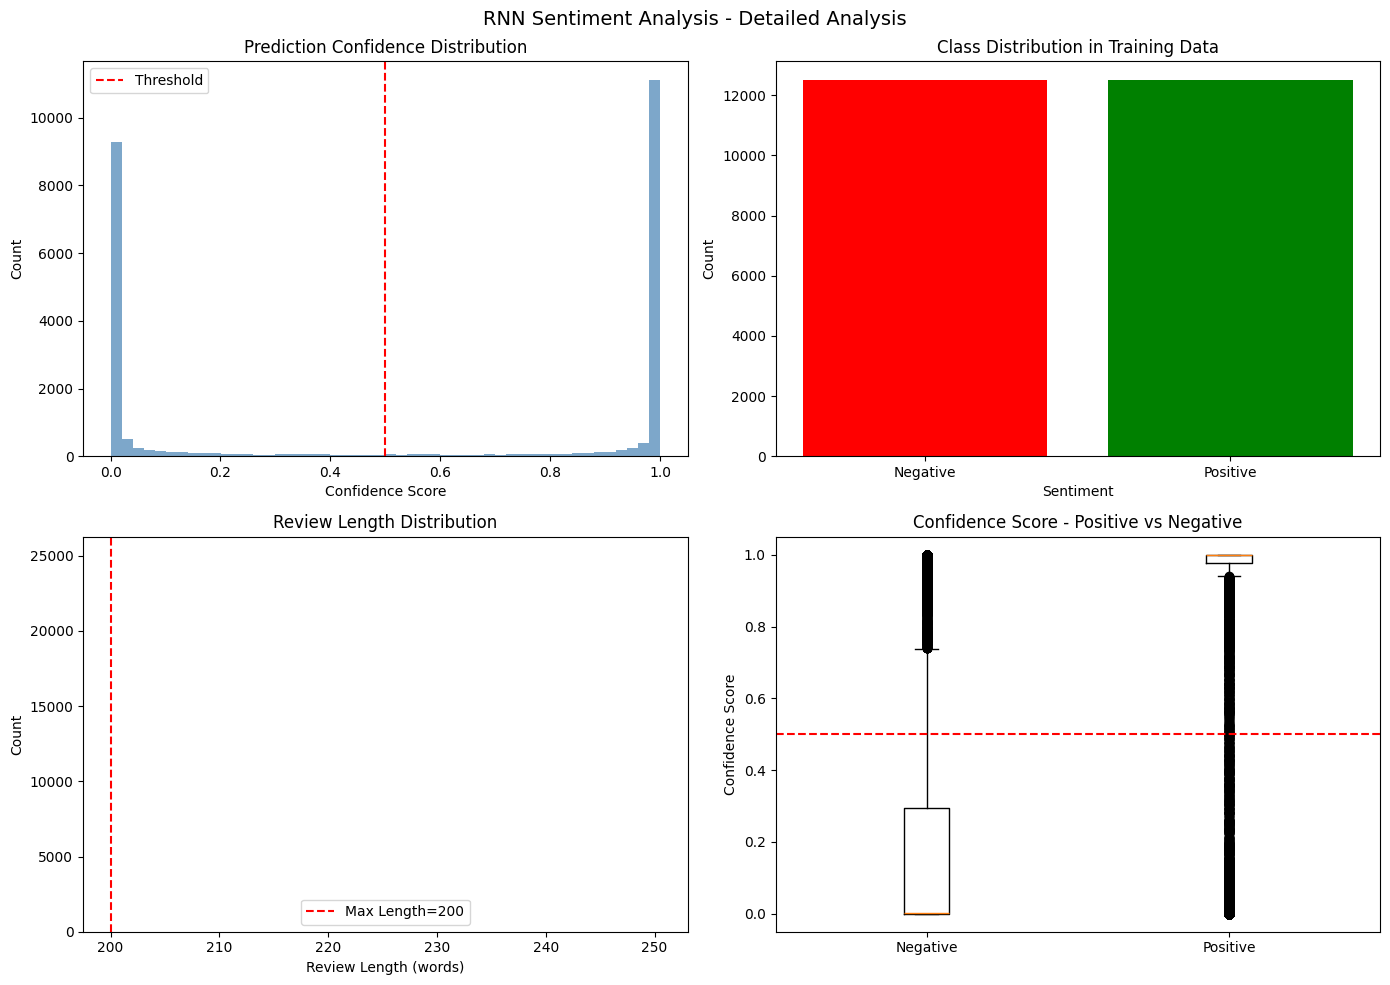

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Prediction Confidence Distribution
y_pred_prob = model.predict(x_test_pad)
axes[0,0].hist(y_pred_prob, bins=50, color='steelblue', alpha=0.7)
axes[0,0].set_title('Prediction Confidence Distribution')
axes[0,0].set_xlabel('Confidence Score')
axes[0,0].set_ylabel('Count')
axes[0,0].axvline(x=0.5, color='red', linestyle='--', label='Threshold')
axes[0,0].legend()

# 2. Class Distribution - Bar Plot
class_counts = np.bincount(y_train)
axes[0,1].bar(['Negative', 'Positive'], class_counts, color=['red', 'green'])
axes[0,1].set_title('Class Distribution in Training Data')
axes[0,1].set_xlabel('Sentiment')
axes[0,1].set_ylabel('Count')

# 3. Review Length Distribution
review_lengths = [len(x) for x in x_train_pad]
axes[1,0].hist(review_lengths, bins=50, color='purple', alpha=0.7)
axes[1,0].set_title('Review Length Distribution')
axes[1,0].set_xlabel('Review Length (words)')
axes[1,0].set_ylabel('Count')
axes[1,0].axvline(x=200, color='red', linestyle='--', label='Max Length=200')
axes[1,0].legend()

# 4. Confidence Box Plot - Positive vs Negative
pos_conf = y_pred_prob[y_test == 1].flatten()
neg_conf = y_pred_prob[y_test == 0].flatten()
axes[1,1].boxplot([neg_conf, pos_conf], tick_labels=['Negative', 'Positive'])
axes[1,1].set_title('Confidence Score - Positive vs Negative')
axes[1,1].set_ylabel('Confidence Score')
axes[1,1].axhline(y=0.5, color='red', linestyle='--')

plt.suptitle('RNN Sentiment Analysis - Detailed Analysis', fontsize=14)
plt.tight_layout()
plt.show()

Six Type Visualization

In [ ]:
print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1 Score:",f1)

print("Unique Predictions:",np.unique(y_pred))
print("Prediction counts:",np.bincount(y_pred.flatten()))

Accuracy: 0.8059999942779541
Precision: 0.0
Recall: 0.0
F1 Score: 0.0
Unique Predictions: [0]
Prediction counts: [25000]


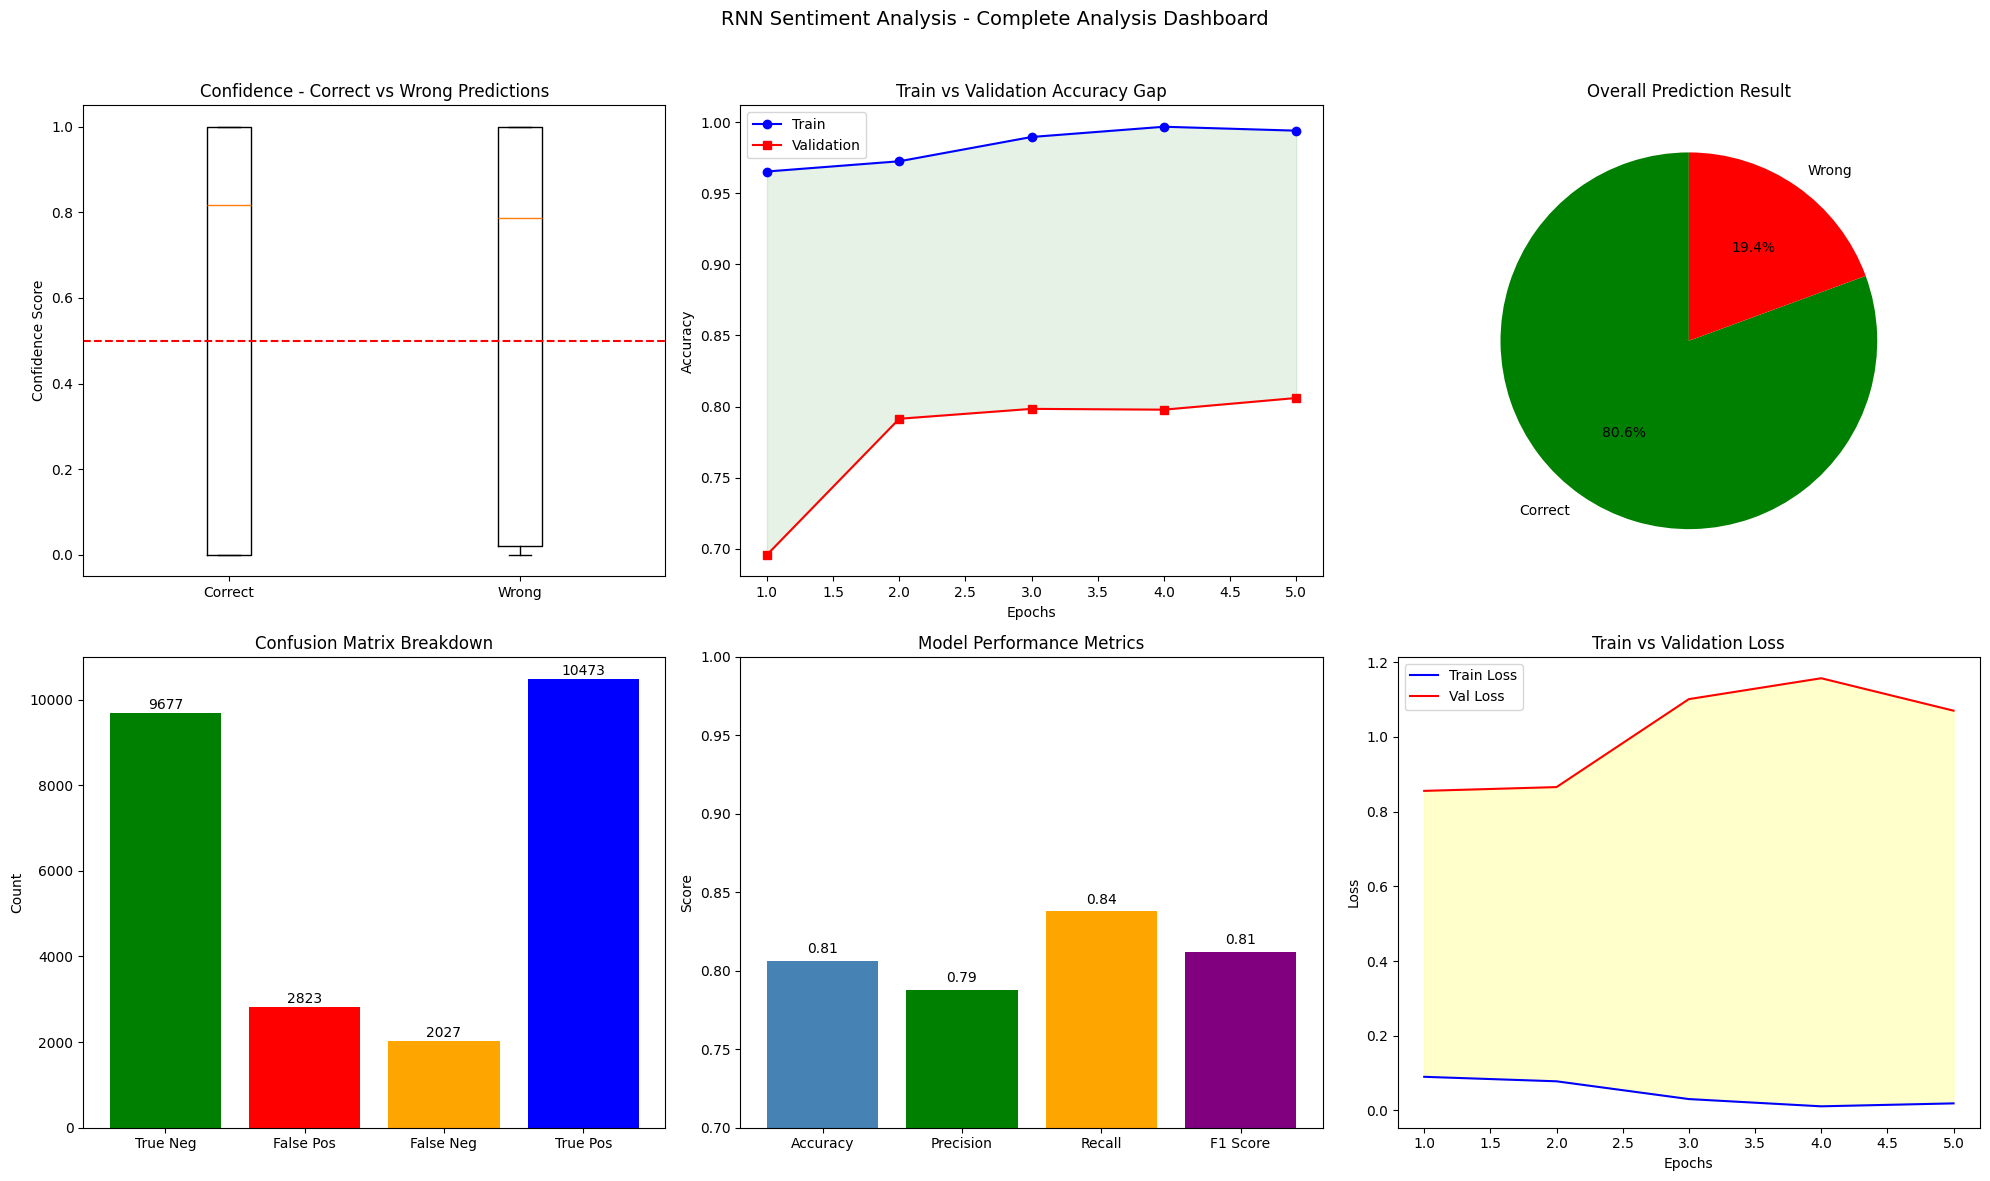

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# 1. Correct vs Wrong Confidence - Box Plot
correct_conf = y_pred_prob[y_test == y_pred.flatten()].flatten()
wrong_conf = y_pred_prob[y_test != y_pred.flatten()].flatten()
axes[0,0].boxplot([correct_conf, wrong_conf], tick_labels=['Correct', 'Wrong'])
axes[0,0].set_title('Confidence - Correct vs Wrong Predictions')
axes[0,0].set_ylabel('Confidence Score')
axes[0,0].axhline(y=0.5, color='red', linestyle='--')

# 2. Epoch vs Accuracy - Line Plot
epochs = range(1, len(history.history['accuracy']) + 1)
axes[0,1].plot(epochs, history.history['accuracy'], 'bo-', label='Train')
axes[0,1].plot(epochs, history.history['val_accuracy'], 'rs-', label='Validation')
axes[0,1].fill_between(epochs,
                        history.history['accuracy'],
                        history.history['val_accuracy'],
                        alpha=0.1, color='green')
axes[0,1].set_title('Train vs Validation Accuracy Gap')
axes[0,1].set_xlabel('Epochs')
axes[0,1].set_ylabel('Accuracy')
axes[0,1].legend()

# 3. Prediction Distribution - Pie Chart
correct = int((y_test == y_pred.flatten()).sum())
wrong = int((y_test != y_pred.flatten()).sum())
axes[0,2].pie([correct, wrong],
              labels=['Correct', 'Wrong'],
              colors=['green', 'red'],
              autopct='%1.1f%%',
              startangle=90)
axes[0,2].set_title('Overall Prediction Result')

# 4. True Positive, True Negative, FP, FN - Bar Plot
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
bars = axes[1,0].bar(['True Neg', 'False Pos', 'False Neg', 'True Pos'],
                      [tn, fp, fn, tp],
                      color=['green', 'red', 'orange', 'blue'])
axes[1,0].set_title('Confusion Matrix Breakdown')
axes[1,0].set_ylabel('Count')
for bar, val in zip(bars, [tn, fp, fn, tp]):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 100,
                   str(val), ha='center', fontsize=10)

# 5. Precision, Recall, F1 - Bar Plot
from sklearn.metrics import precision_score, recall_score, f1_score
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]
colors = ['steelblue', 'green', 'orange', 'purple']
bars2 = axes[1,1].bar(metrics, values, color=colors)
axes[1,1].set_title('Model Performance Metrics')
axes[1,1].set_ylabel('Score')
axes[1,1].set_ylim([0.7, 1.0])
for bar, val in zip(bars2, values):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.005,
                   f'{val:.2f}', ha='center', fontsize=10)

# 6. Loss Curve with Fill
axes[1,2].plot(epochs, history.history['loss'], 'b-', label='Train Loss')
axes[1,2].plot(epochs, history.history['val_loss'], 'r-', label='Val Loss')
axes[1,2].fill_between(epochs,
                        history.history['loss'],
                        history.history['val_loss'],
                        alpha=0.2, color='yellow')
axes[1,2].set_title('Train vs Validation Loss')
axes[1,2].set_xlabel('Epochs')
axes[1,2].set_ylabel('Loss')
axes[1,2].legend()

plt.suptitle('RNN Sentiment Analysis - Complete Analysis Dashboard', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()
